In [1]:
!pip install -q timm scikit-learn

In [18]:
!tar -xf /content/drive/MyDrive/DNN_Dataset/vit_crops_224.tar -C /content

In [3]:
import os
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import timm

import matplotlib.pyplot as plt
from PIL import Image

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Imports loaded.")

Imports loaded.


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
MODEL_PATH = Path('/content/drive/MyDrive/DNN_Dataset/SeaDronesSee_SwinB/best_swin_b.pth')
DATA_ROOT = Path('/content/vit_crops_224')
TEST_DIR = DATA_ROOT / 'test'

REPORT_DIR = Path('/content/swin_b_visual_reports')
REPORT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Device:', DEVICE)
print('Model exists:', MODEL_PATH.exists(), MODEL_PATH)
print('Test folder exists:', TEST_DIR.exists(), TEST_DIR)

if not MODEL_PATH.exists():
    raise FileNotFoundError(f'Model checkpoint not found: {MODEL_PATH}')

if not TEST_DIR.exists():
    raise FileNotFoundError(f'Test folder not found: {TEST_DIR}')

Device: cuda
Model exists: True /content/drive/MyDrive/DNN_Dataset/SeaDronesSee_SwinB/best_swin_b.pth
Test folder exists: True /content/vit_crops_224/test


## Build test DataLoader

In [20]:
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print('Classes:', test_ds.classes)
print('Class to idx:', test_ds.class_to_idx)
print('Test images:', len(test_ds))

# Count images per class
for cls_name, cls_idx in test_ds.class_to_idx.items():
    count = sum(1 for _, label in test_ds.samples if label == cls_idx)
    print(f'{cls_name:25s}: {count}')

Classes: ['boat', 'buoy', 'jetski', 'life_saving_appliances', 'swimmer']
Class to idx: {'boat': 0, 'buoy': 1, 'jetski': 2, 'life_saving_appliances': 3, 'swimmer': 4}
Test images: 750
boat                     : 150
buoy                     : 150
jetski                   : 150
life_saving_appliances   : 150
swimmer                  : 150


## Build Swin-B architecture and load checkpoint

In [21]:
def extract_state_dict(checkpoint):
    """Return a PyTorch state_dict from either a raw state_dict or a checkpoint dictionary."""
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        print('Checkpoint format: dictionary with model_state_dict')
        return checkpoint['model_state_dict'], checkpoint
    elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        print('Checkpoint format: dictionary with state_dict')
        return checkpoint['state_dict'], checkpoint
    else:
        print('Checkpoint format: raw state_dict')
        return checkpoint, {}


def remove_module_prefix(state_dict):
    """Remove DataParallel 'module.' prefix if present."""
    new_state = {}
    for k, v in state_dict.items():
        if k.startswith('module.'):
            new_state[k[len('module.'):]] = v
        else:
            new_state[k] = v
    return new_state


def build_and_load_swin(checkpoint_path, num_classes=5, device='cpu'):
    """
    Try common Swin-B timm model names until the checkpoint loads strictly.
    This avoids rerunning any training code from another notebook.
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict, checkpoint_meta = extract_state_dict(checkpoint)
    state_dict = remove_module_prefix(state_dict)

    candidate_model_names = [
        'swin_base_patch4_window7_224.ms_in22k_ft_in1k',
        'swin_base_patch4_window7_224',
    ]

    last_error = None
    for model_name in candidate_model_names:
        try:
            print(f'\nTrying architecture: {model_name}')
            model = timm.create_model(
                model_name,
                pretrained=False,
                num_classes=num_classes
            )
            model.load_state_dict(state_dict, strict=True)
            model = model.to(device)
            model.eval()
            print(f'✅ Loaded checkpoint successfully with: {model_name}')
            return model, checkpoint_meta, model_name
        except Exception as e:
            last_error = e
            print(f'❌ Failed with {model_name}: {e}')

    raise RuntimeError(
        'Could not load checkpoint with the candidate Swin-B architectures. '
        'Check the exact timm model name used during training. '
        f'Last error: {last_error}'
    )


model, checkpoint, loaded_model_name = build_and_load_swin(
    MODEL_PATH,
    num_classes=NUM_CLASSES,
    device=DEVICE
)

print('\nLoaded model name:', loaded_model_name)
print('Checkpoint epoch:', checkpoint.get('epoch', 'unknown'))
print('Checkpoint stage:', checkpoint.get('stage', 'unknown'))
print('Best val macro F1:', checkpoint.get('val_macro_f1', 'unknown'))

Checkpoint format: dictionary with model_state_dict

Trying architecture: swin_base_patch4_window7_224.ms_in22k_ft_in1k
✅ Loaded checkpoint successfully with: swin_base_patch4_window7_224.ms_in22k_ft_in1k

Loaded model name: swin_base_patch4_window7_224.ms_in22k_ft_in1k
Checkpoint epoch: 11
Checkpoint stage: fine_tune
Best val macro F1: 0.9895062887225711


## Map Class names

In [22]:
if isinstance(checkpoint, dict) and 'idx_to_class' in checkpoint:
    idx_to_class = {int(k): v for k, v in checkpoint['idx_to_class'].items()}
    class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]
else:
    class_names = test_ds.classes

print('Class names:', class_names)

Class names: ['boat', 'buoy', 'jetski', 'life_saving_appliances', 'swimmer']


## Evaluate model on test set

In [23]:
@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)

        logits = model(images)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )


y_true, y_pred, y_probs = evaluate_model(model, test_loader, DEVICE)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f'Accuracy:    {acc:.4f}')
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')

print('\nClassification Report:')
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

Accuracy:    0.9920
Macro F1:    0.9920
Weighted F1: 0.9920

Classification Report:
                        precision    recall  f1-score   support

                  boat       1.00      0.99      0.99       150
                  buoy       0.99      1.00      1.00       150
                jetski       0.99      1.00      1.00       150
life_saving_appliances       1.00      0.97      0.99       150
               swimmer       0.97      1.00      0.99       150

              accuracy                           0.99       750
             macro avg       0.99      0.99      0.99       750
          weighted avg       0.99      0.99      0.99       750



## Confusion matrix

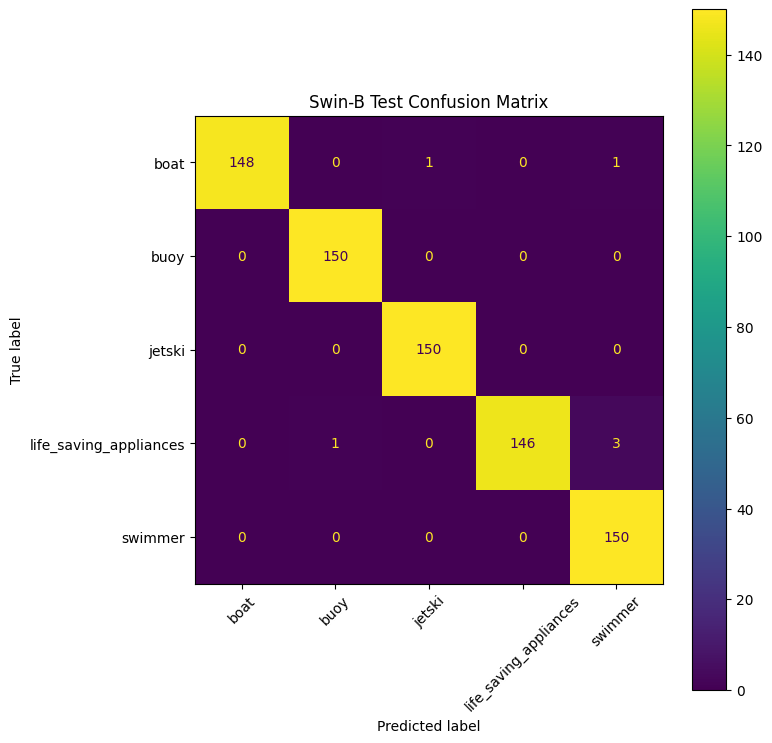

Saved: /content/swin_b_visual_reports/confusion_matrix.png


In [24]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format='d'
)
plt.title('Swin-B Test Confusion Matrix')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'confusion_matrix.png', dpi=200)
plt.show()

print('Saved:', REPORT_DIR / 'confusion_matrix.png')

## Normalized confusion matrix

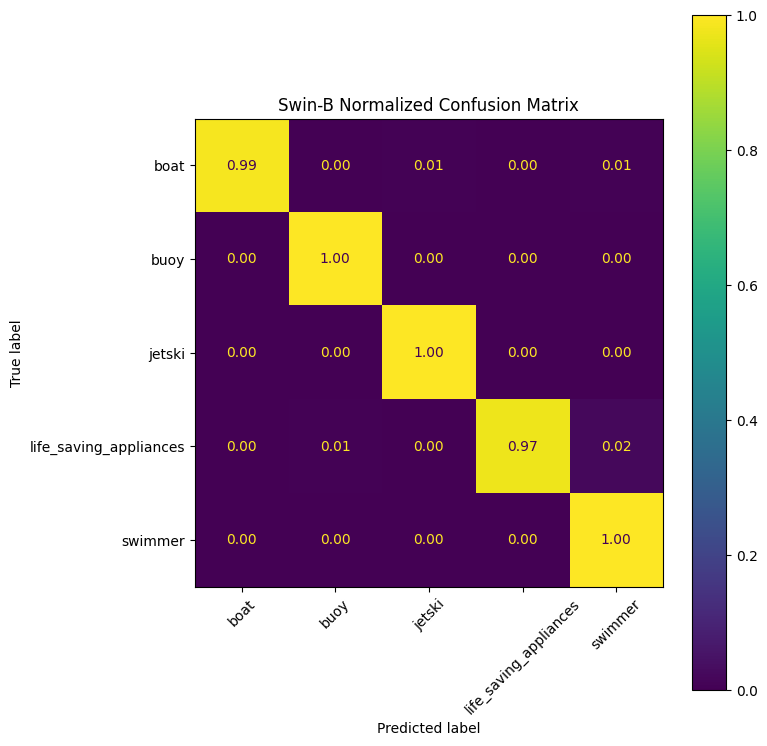

Saved: /content/swin_b_visual_reports/confusion_matrix_normalized.png


In [25]:
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format='.2f'
)
plt.title('Swin-B Normalized Confusion Matrix')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'confusion_matrix_normalized.png', dpi=200)
plt.show()

print('Saved:', REPORT_DIR / 'confusion_matrix_normalized.png')

## Per-class precision, recall, and F1

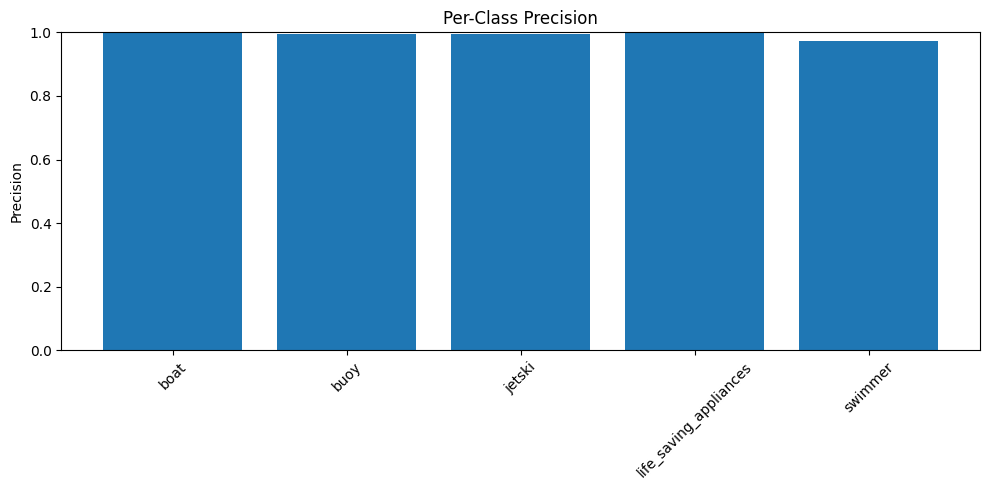

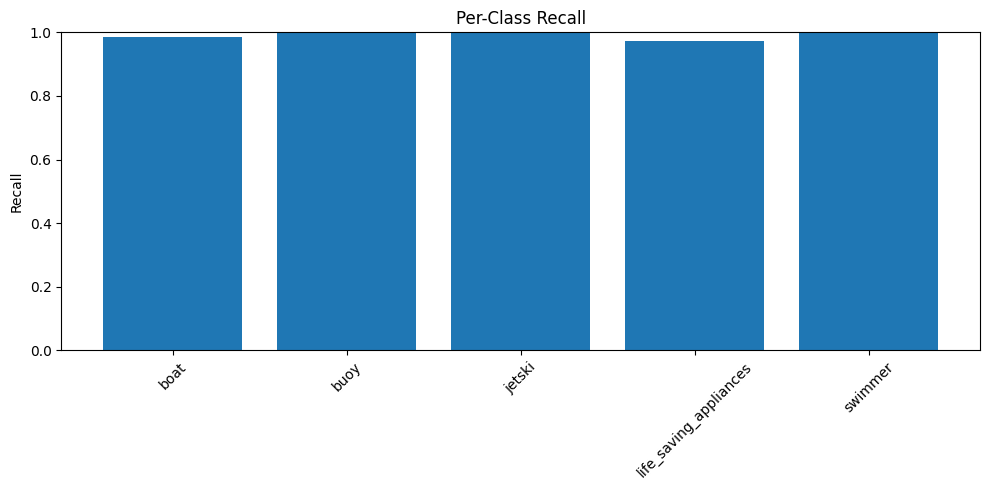

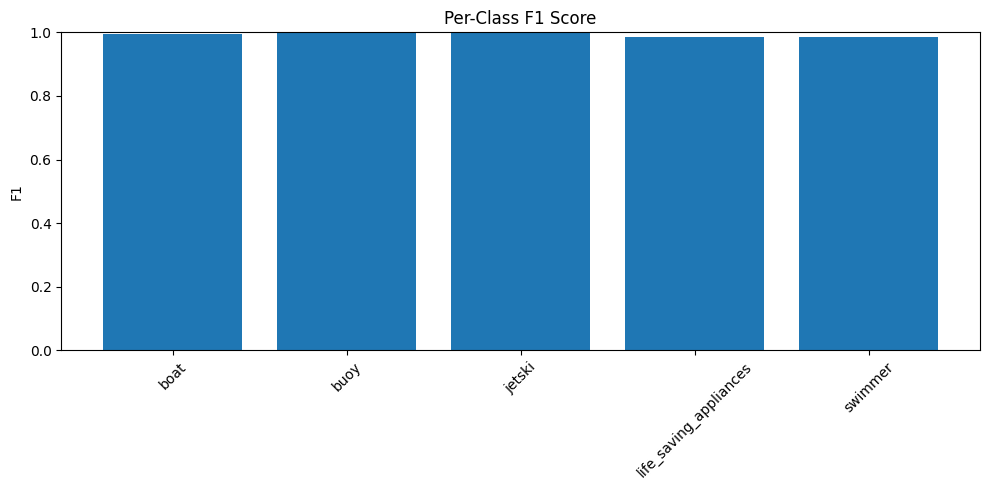

boat                      | Precision: 1.0000 | Recall: 0.9867 | F1: 0.9933 | Support: 150
buoy                      | Precision: 0.9934 | Recall: 1.0000 | F1: 0.9967 | Support: 150
jetski                    | Precision: 0.9934 | Recall: 1.0000 | F1: 0.9967 | Support: 150
life_saving_appliances    | Precision: 1.0000 | Recall: 0.9733 | F1: 0.9865 | Support: 150
swimmer                   | Precision: 0.9740 | Recall: 1.0000 | F1: 0.9868 | Support: 150


In [26]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    zero_division=0
)

x = np.arange(NUM_CLASSES)

plt.figure(figsize=(10, 5))
plt.bar(x, precision)
plt.xticks(x, class_names, rotation=45)
plt.ylim(0, 1)
plt.title('Per-Class Precision')
plt.ylabel('Precision')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'per_class_precision.png', dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x, recall)
plt.xticks(x, class_names, rotation=45)
plt.ylim(0, 1)
plt.title('Per-Class Recall')
plt.ylabel('Recall')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'per_class_recall.png', dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x, f1)
plt.xticks(x, class_names, rotation=45)
plt.ylim(0, 1)
plt.title('Per-Class F1 Score')
plt.ylabel('F1')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'per_class_f1.png', dpi=200)
plt.show()

for i, cls in enumerate(class_names):
    print(
        f'{cls:25s} | '
        f'Precision: {precision[i]:.4f} | '
        f'Recall: {recall[i]:.4f} | '
        f'F1: {f1[i]:.4f} | '
        f'Support: {support[i]}'
    )

## Confidence distribution

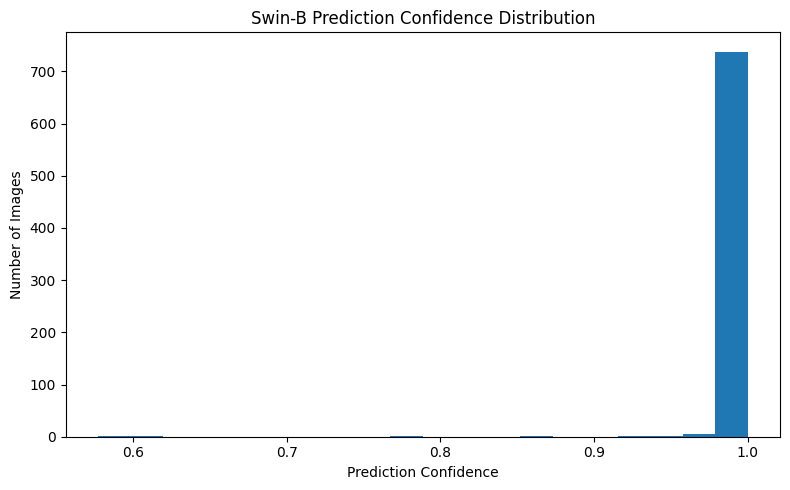

Mean confidence: 0.99778783
Min confidence: 0.5772078
Max confidence: 1.0


In [27]:
max_conf = y_probs.max(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(max_conf, bins=20)
plt.xlabel('Prediction Confidence')
plt.ylabel('Number of Images')
plt.title('Swin-B Prediction Confidence Distribution')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'confidence_histogram.png', dpi=200)
plt.show()

print('Mean confidence:', max_conf.mean())
print('Min confidence:', max_conf.min())
print('Max confidence:', max_conf.max())

## Random prediction grid

Saved: /content/swin_b_visual_reports/random_predictions.png


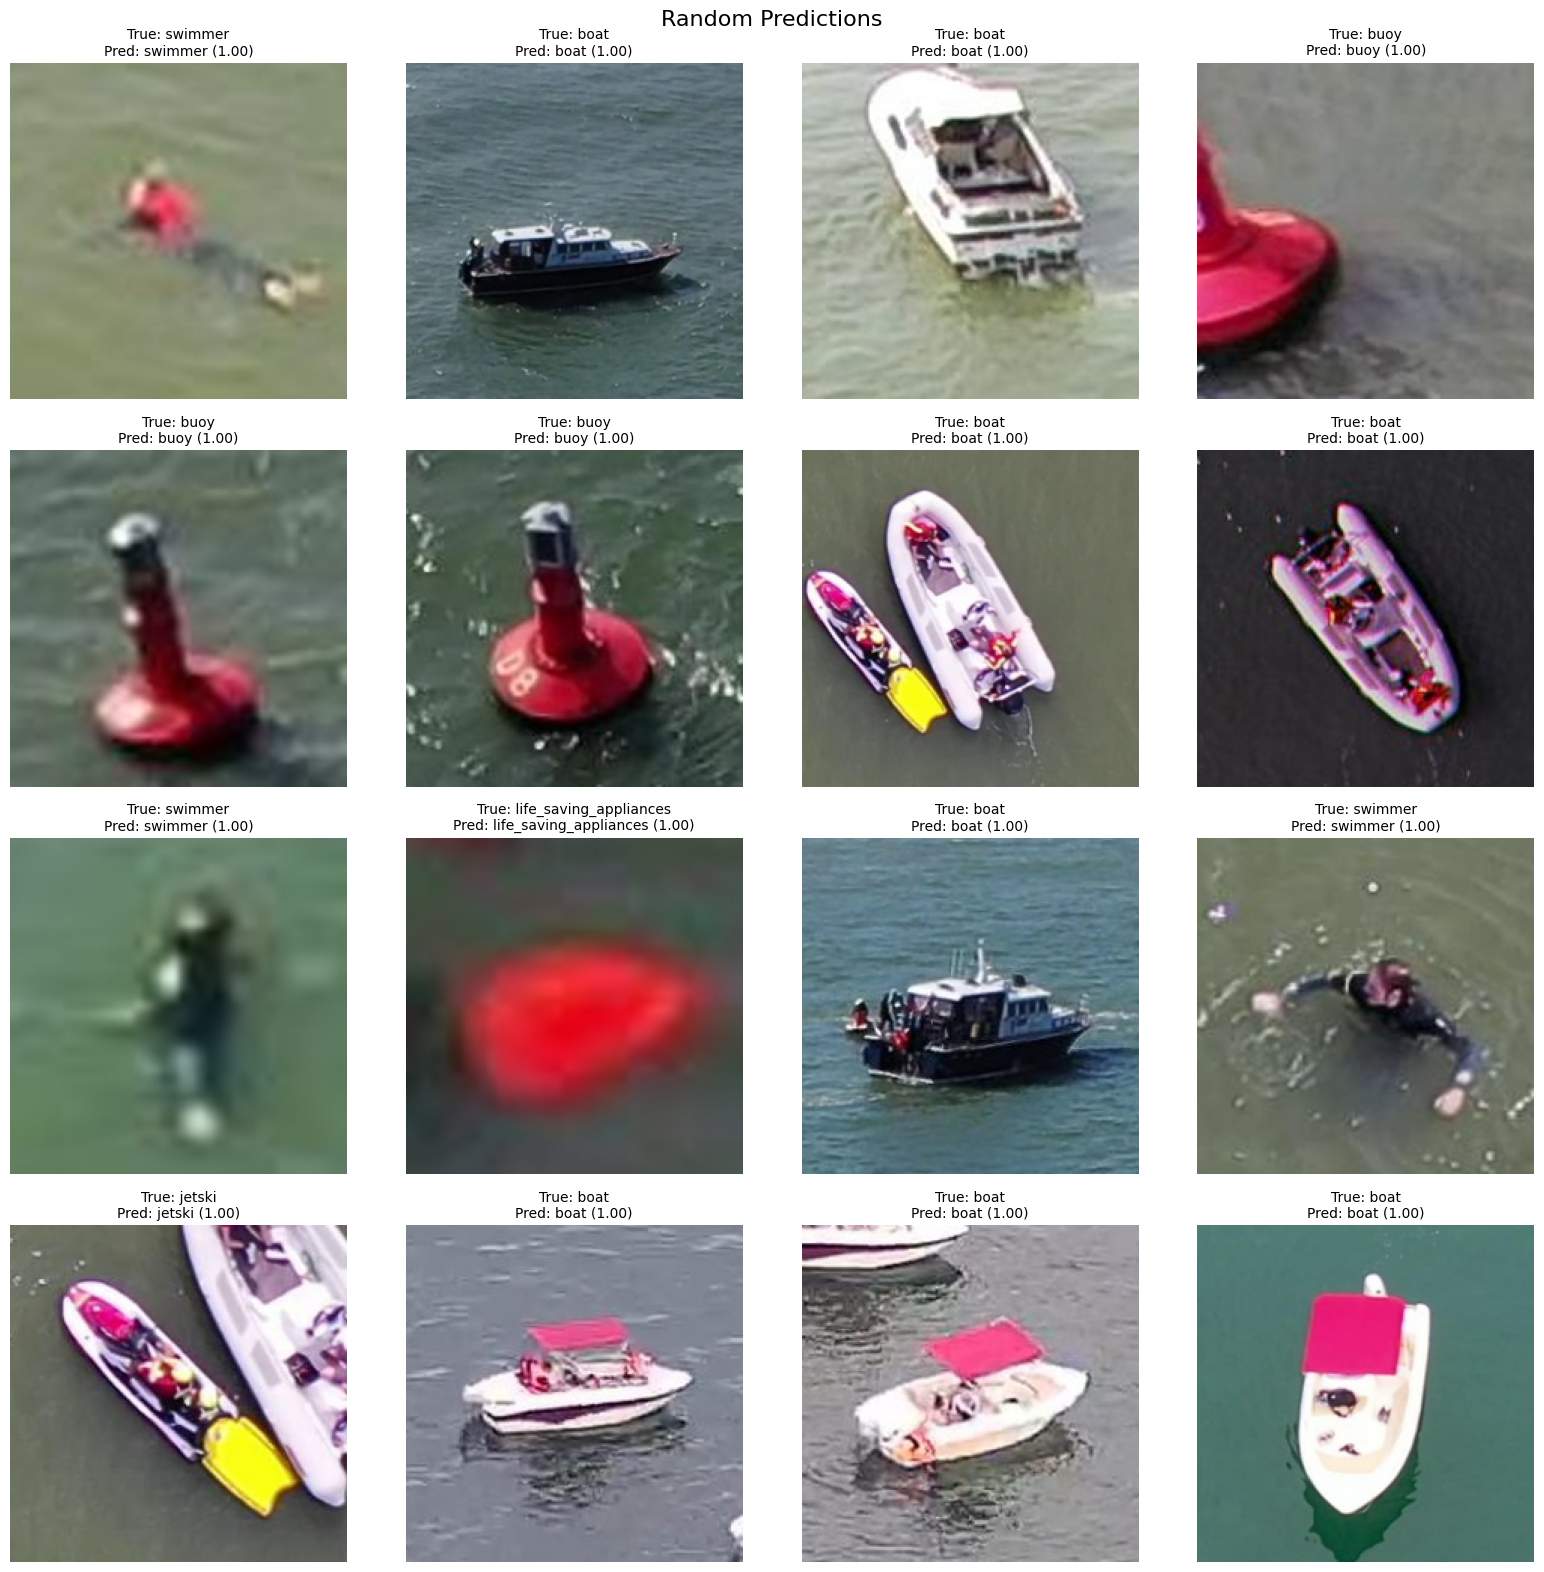

In [28]:
def show_prediction_grid(dataset, y_true, y_pred, y_probs, class_names, n=16, only_wrong=False, save_path=None):
    paths = [p for p, _ in dataset.samples]

    if only_wrong:
        indices = np.where(y_true != y_pred)[0]
        title = 'Wrong Predictions'
    else:
        indices = np.arange(len(dataset))
        title = 'Random Predictions'

    if len(indices) == 0:
        print('No images to show.')
        return

    selected = random.sample(list(indices), min(n, len(indices)))

    cols = 4
    rows = int(np.ceil(len(selected) / cols))

    plt.figure(figsize=(cols * 4, rows * 4))

    for i, idx in enumerate(selected):
        img_path = paths[idx]
        img = Image.open(img_path).convert('RGB')

        true_name = class_names[y_true[idx]]
        pred_name = class_names[y_pred[idx]]
        conf = y_probs[idx, y_pred[idx]]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(
            f'True: {true_name}\nPred: {pred_name} ({conf:.2f})',
            fontsize=10
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)
        print('Saved:', save_path)

    plt.show()


show_prediction_grid(
    test_ds,
    y_true,
    y_pred,
    y_probs,
    class_names,
    n=16,
    only_wrong=False,
    save_path=REPORT_DIR / 'random_predictions.png'
)

##  Wrong prediction grid

Saved: /content/swin_b_visual_reports/wrong_predictions.png


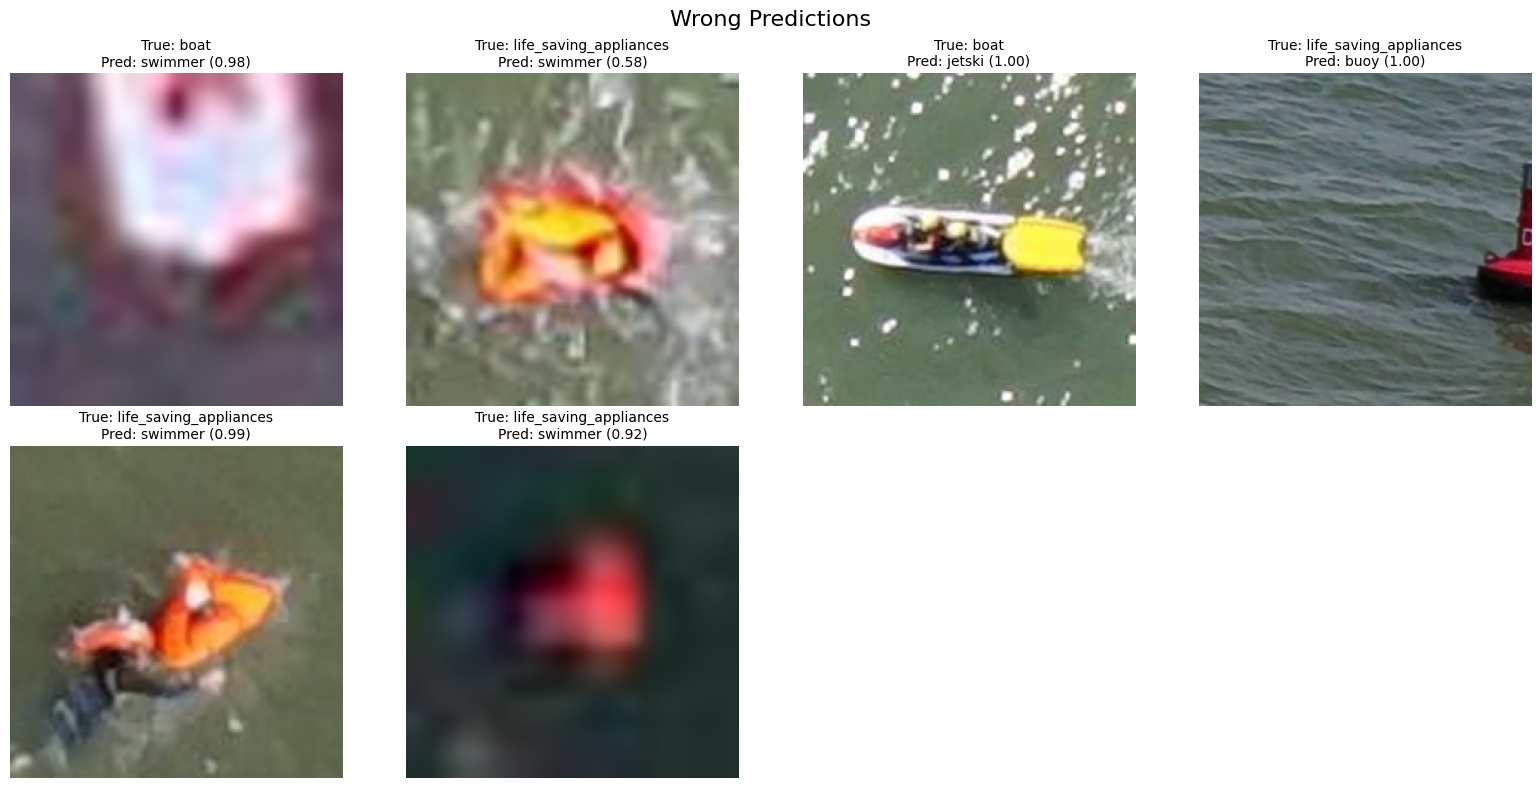

In [29]:
show_prediction_grid(
    test_ds,
    y_true,
    y_pred,
    y_probs,
    class_names,
    n=16,
    only_wrong=True,
    save_path=REPORT_DIR / 'wrong_predictions.png'
)

## Show top-k probabilities for one crop

{
    "image_path": "/content/vit_crops_224/test/boat/10160_obj1_cls2.jpg",
    "pred_class_id": 0,
    "pred_class_name": "boat",
    "confidence": 0.9991258978843689,
    "top_probs": [
        [
            "boat",
            0.9991258978843689
        ],
        [
            "swimmer",
            0.0008652953547425568
        ],
        [
            "life_saving_appliances",
            5.579413482337259e-06
        ],
        [
            "buoy",
            2.9032839847786818e-06
        ],
        [
            "jetski",
            4.1569640529814933e-07
        ]
    ]
}


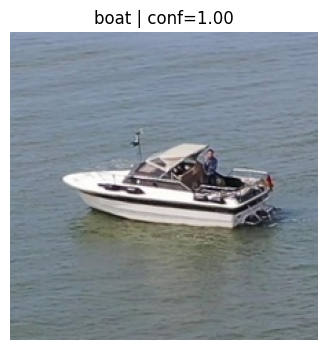

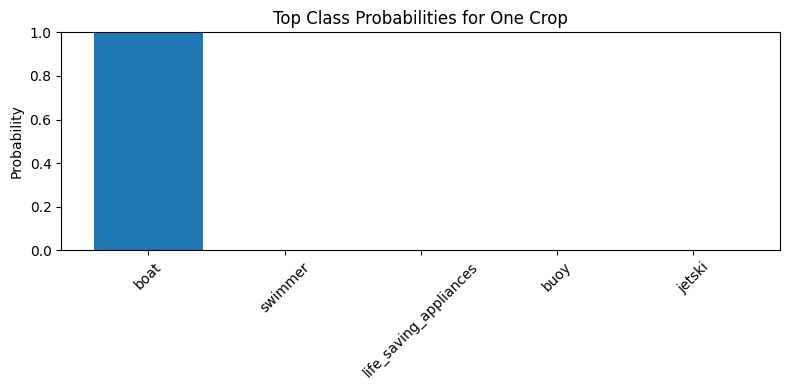

In [30]:
infer_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

@torch.no_grad()
def predict_one_crop(image_path, top_k=5):
    img = Image.open(image_path).convert('RGB')
    x = infer_tfms(img).unsqueeze(0).to(DEVICE)

    logits = model(x)
    probs = F.softmax(logits, dim=1)[0].cpu().numpy()

    order = np.argsort(probs)[::-1][:top_k]

    result = {
        'image_path': str(image_path),
        'pred_class_id': int(order[0]),
        'pred_class_name': class_names[int(order[0])],
        'confidence': float(probs[order[0]]),
        'top_probs': [(class_names[int(i)], float(probs[i])) for i in order]
    }
    return result


sample_path = test_ds.samples[0][0]
result = predict_one_crop(sample_path)

print(json.dumps(result, indent=4))

img = Image.open(sample_path).convert('RGB')
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"{result['pred_class_name']} | conf={result['confidence']:.2f}")
plt.show()

# Bar chart of probabilities
labels = [x[0] for x in result['top_probs']]
probs = [x[1] for x in result['top_probs']]

plt.figure(figsize=(8, 4))
plt.bar(labels, probs)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.ylabel('Probability')
plt.title('Top Class Probabilities for One Crop')
plt.tight_layout()
plt.show()

## Save metrics JSON

In [31]:
metrics = {
    'accuracy': float(acc),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'classes': class_names,
    'precision': precision.tolist(),
    'recall': recall.tolist(),
    'f1': f1.tolist(),
    'support': support.tolist(),
    'confusion_matrix': cm.tolist(),
    'normalized_confusion_matrix': cm_norm.tolist(),
    'model_path': str(MODEL_PATH),
    'loaded_model_name': loaded_model_name,
}

with open(REPORT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print('✅ Reports saved to:', REPORT_DIR)
print('Files:')
for p in sorted(REPORT_DIR.glob('*')):
    print(' -', p)

✅ Reports saved to: /content/swin_b_visual_reports
Files:
 - /content/swin_b_visual_reports/confidence_histogram.png
 - /content/swin_b_visual_reports/confusion_matrix.png
 - /content/swin_b_visual_reports/confusion_matrix_normalized.png
 - /content/swin_b_visual_reports/metrics.json
 - /content/swin_b_visual_reports/per_class_f1.png
 - /content/swin_b_visual_reports/per_class_precision.png
 - /content/swin_b_visual_reports/per_class_recall.png
 - /content/swin_b_visual_reports/random_predictions.png
 - /content/swin_b_visual_reports/wrong_predictions.png
